In [1]:
import numpy as np
from scipy.integrate import solve_ivp as sp_solve_ivp
from scipy.integrate import odeint
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from typing import List
device = 'cpu'
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from ftnode.utils import set_global_seed
from ftnode.node import (
    FTNODE, FeluSigmoidMLP, GeluSigmoidMLP,)

import torchode

seed = 1234
set_global_seed(seed)

random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
## Define system 
gamma = 50
def sigmoid(x,gamma=gamma):
    return 1 / (1+np.exp(-gamma*x))

eps = 0.02
q1, q2 = (0.08, 0.04)
b1 = 1-eps
b2 = 1-eps

def c1_in(x):
    return q1*(1-sigmoid(x-b1))

def c2_in(y):
    return q1*(1-sigmoid(y-b2))

def c1_out(y):
    return q2*(1-sigmoid(y-b2))

def c2_out(y):
    return q2

def two_tank_system(t,x,u):
    x1, x2 = x
    p, v = u
    x1= np.maximum(x1,0)
    x2 = np.maximum(x2,0)
    dx1dt = c1_in(x1)*(1-v)*p-c1_out(x2)*np.sqrt(x1)
    dx2dt = c2_in(x2)*v*p +c1_out(x2)*np.sqrt(x1)-q2*np.sqrt(x2)
    return np.hstack([dx1dt,dx2dt])


p_vals = np.linspace(0,1,101)
v_vals = np.linspace(0,1,101)

In [3]:
f = FeluSigmoidMLP(dims=[2,20,20,20,2],lower_bound=-1, upper_bound=-0.1)
g = GeluSigmoidMLP(dims=[4,20,20,20,2],lower_bound=0, upper_bound=1)
model = FTNODE(f,g).to(device)

model_path = "../best_model-20-20-20.pth"

model.load_state_dict(torch.load(model_path))

model.eval()

FTNODE(
  (f): FeluSigmoidMLP(
    (activation): SiLU()
    (network): MLP(
      (activation): SiLU()
      (layers): ModuleList(
        (0): Linear(in_features=2, out_features=20, bias=True)
        (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
        (3): Linear(in_features=20, out_features=2, bias=True)
      )
    )
  )
  (g): GeluSigmoidMLP(
    (activation): SiLU()
    (network): MLP(
      (activation): SiLU()
      (layers): ModuleList(
        (0): Linear(in_features=4, out_features=20, bias=True)
        (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
        (3): Linear(in_features=20, out_features=2, bias=True)
      )
    )
  )
)

In [4]:
# Given parameters
from scipy.optimize import root
t_span = (0, 1500)

pi = .5
vi = 0.5

p_vals = np.linspace(0,1,5)
v_vals = np.linspace(0,1,5)
p_vals[0] = 0.05
v_vals[0] = 0.05
p_vals[-1] = 0.95
v_vals[-1] = 0.95

x_inits = [[0.1,0.1],[.9,0.2],[0.2,.9],[0.1,0.6],[0.6,0.1],[0.8,0.8]]

n_points = 21
eps = 1e-2

x1_lin = np.linspace(0, 1+eps, n_points)
x2_lin = np.linspace(0, 1+eps, n_points)
X1, X2 = np.meshgrid(x1_lin, x2_lin)

prev_eq = np.array([0.5,0.5])

  0%|          | 0/5 [00:00<?, ?it/s]

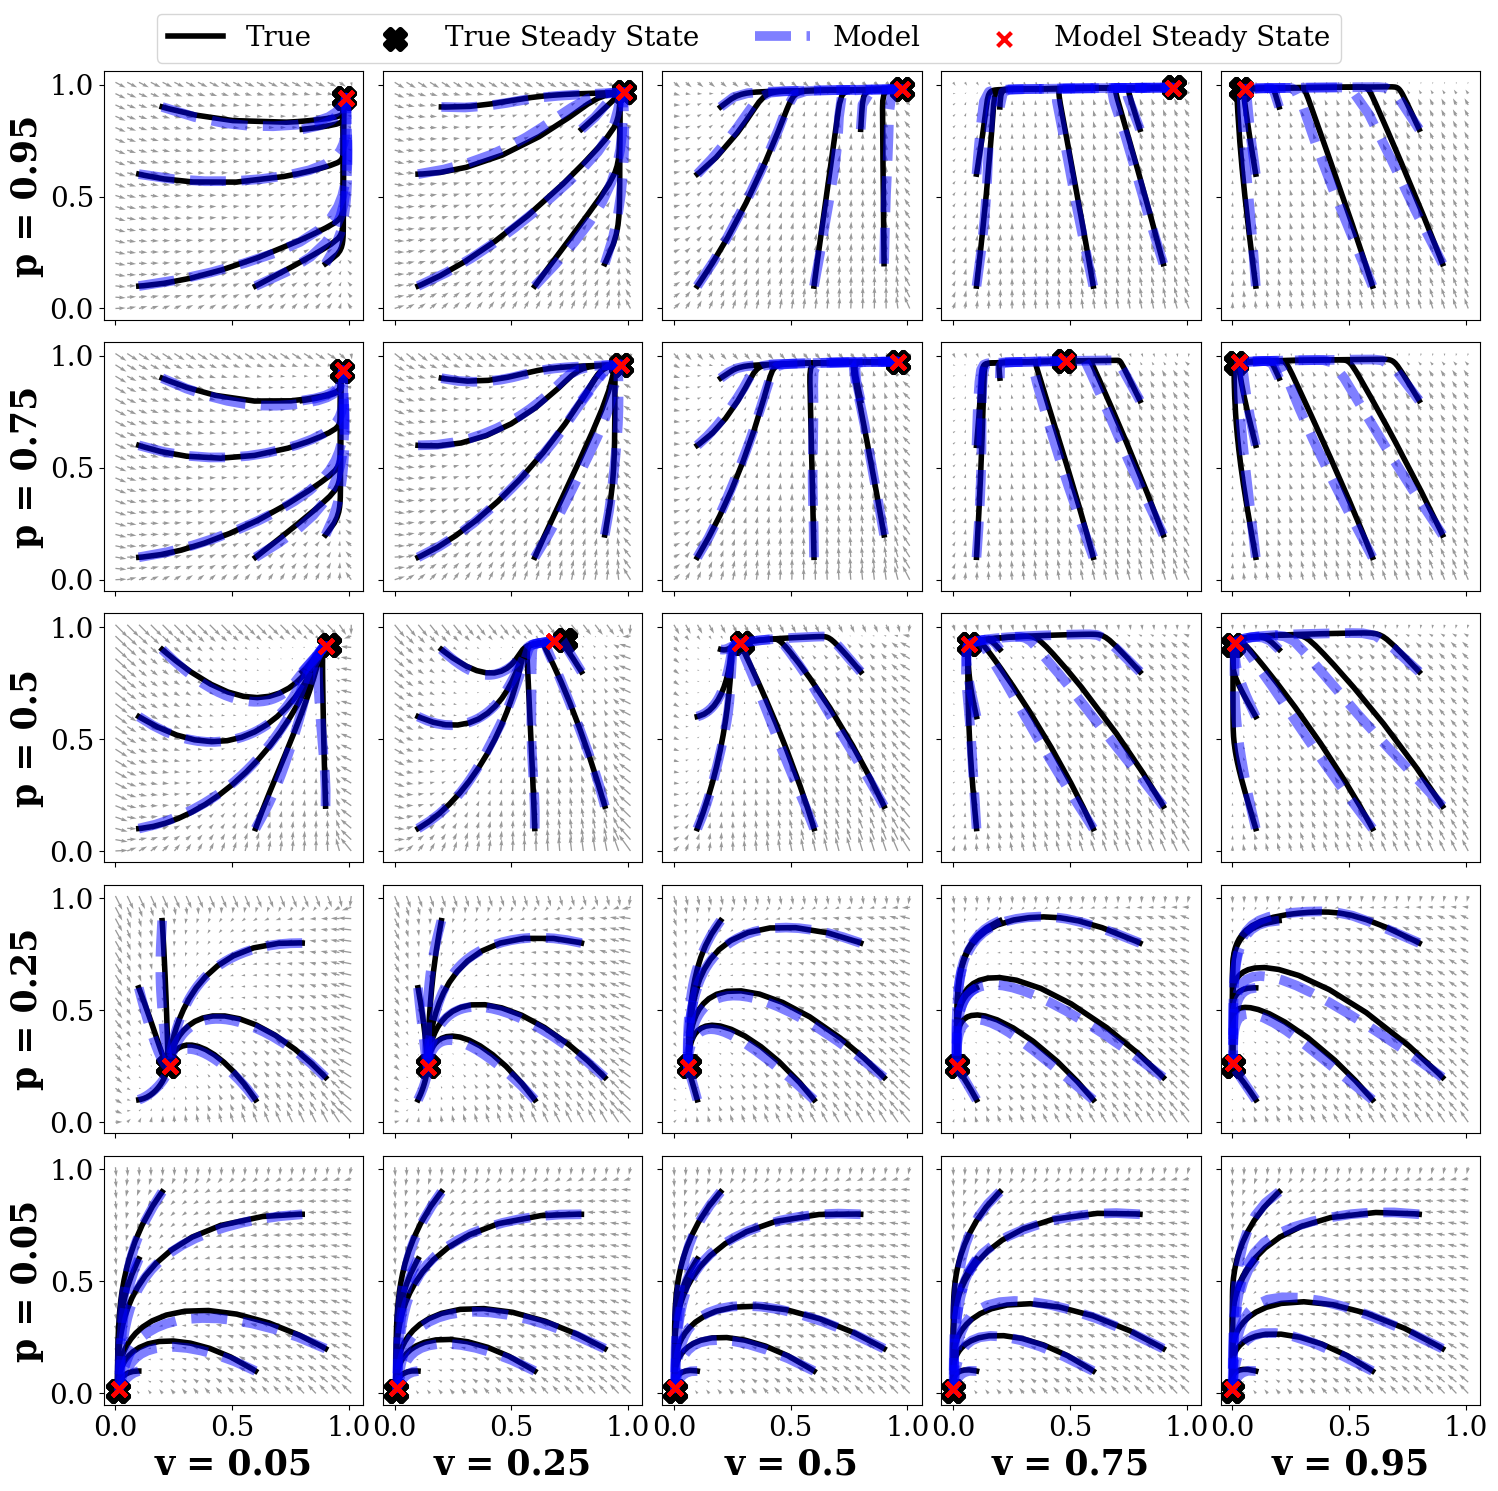

In [5]:
fig_scale = 3
figsize = (int(fig_scale*len(p_vals)), int(fig_scale*len(v_vals)))

fig, axes = plt.subplots(
    len(p_vals), len(v_vals),
    figsize=figsize,
    # constrained_layout=True,
    sharex=True,
    sharey=True
)

Ti = torch.linspace(t_span[0], t_span[-1], 501, dtype=torch.float32)

for i, pi in enumerate(tqdm(p_vals[::-1])):
    for j, vj in enumerate(v_vals):
        ax = axes[i, j]

        # ======================================================
        # TRUE VECTOR FIELD
        # ======================================================
        U = np.zeros_like(X1)
        V = np.zeros_like(X2)

        for ii in range(X1.shape[0]):
            for jj in range(X1.shape[1]):
                x = np.array([X1[ii, jj], X2[ii, jj]])
                dxdt = two_tank_system(0, x, (pi, vj))
                U[ii, jj] = dxdt[0]
                V[ii, jj] = dxdt[1]

        ax.quiver(
            X1, X2, U, V,
            angles='xy',
            scale_units='xy',
            width=0.005,
            color='grey',
            alpha=0.8
        )

        # ======================================================
        # TRUE TRAJECTORIES (solid)
        # ======================================================
        for idx, x0 in enumerate(x_inits):
            label = None
            if idx ==0:
                label = "True"
            sol_true = sp_solve_ivp(
                lambda t, y: two_tank_system(t, y, (pi, vj)),
                t_span,
                x0,
                rtol=1e-6,
                atol=1e-9
            )

            ax.plot(
                sol_true.y[0],
                sol_true.y[1],
                '-',
                c='black',
                lw=4,
                zorder=1,
                label=label
            )
            label=None
            if idx ==0:
                label = "True Steady State"
            x_last = sol_true.y[:, -1]
            ax.scatter(
                x_last[0], x_last[1],
                marker='X',
                s=200,
                c='black',
                lw=4,
                zorder=3,
                label=label
            )

        # ======================================================
        # MODEL TRAJECTORIES (dashed)
        # ======================================================
        x0_torch = torch.tensor(x_inits, dtype=torch.float32)
        n_x0, dim_x0 = x0_torch.shape

        control = lambda t: torch.tensor([pi, vj], dtype=torch.float32).expand(n_x0, dim_x0)
        func = lambda t, x: model(t, x, control)

        with torch.no_grad():
            sol_model = torchode.solve_ivp(
                f=func,
                y0=x0_torch,
                t_eval=Ti,
            )

        for idx,traj in enumerate(sol_model.ys):
            label=None
            if idx ==0:
                label = "Model"
            ax.plot(
                traj[:, 0].numpy(),
                traj[:, 1].numpy(),
                '--',              # <-- dashed
                lw=7,
                color='blue',
                alpha=0.5,
                zorder=3,
                label = label
            )
            x_last = traj[-1,:].numpy()
            
            label = None
            if idx ==0:
                label = "Model Steady State"
            ax.scatter(x_last[0],x_last[1], marker='x',s=100,c='red',lw=3,zorder=4,label =label)


        # ======================================================
        # LABELS / FORMATTING
        # ======================================================
        if j == 0:
            ax.set_ylabel(f"p = {pi}", size=25, fontweight='bold')

        if i == len(v_vals) - 1:
            ax.set_xlabel(f"v = {vj}", size=25, fontweight='bold')

        ax.tick_params(axis='both', which='major', labelsize=20)

# plt.suptitle(
#     "Phase Portrait: True System (solid) vs Model (dashed)",
#     size=60
# )

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5,fontsize=20)

plt.tight_layout(rect=[0,0,1,0.96])
# plt.savefig("mixing-tanks-phase-portrait.png")
plt.show()


In [6]:
from torch.autograd.functional import jacobian as torch_jacobian

n_p, n_v, n_traj = len(p_vals), len(v_vals), len(x_inits)

# eigenvalues[p_idx, v_idx, traj_idx, eig_idx] — complex
# p_idx indexes p_vals, v_idx indexes v_vals, traj_idx indexes x_inits
eigenvalues = np.empty((n_p, n_v, n_traj, 2), dtype=complex)

t_fixed = torch.tensor(0.0, dtype=torch.float32)
x0_torch = torch.tensor(x_inits, dtype=torch.float32)

model.eval()

for i, pi in enumerate(tqdm(p_vals, desc='p')):
    for j, vj in enumerate(v_vals):
        u = torch.tensor([pi, vj], dtype=torch.float32)

        # Simulate model to find steady states x*
        ctrl_fn = lambda t, _u=u: _u.expand(n_traj, 2)

        with torch.no_grad():
            sol_model = torchode.solve_ivp(
                f=lambda t, x, _c=ctrl_fn: model(t, x, _c),
                y0=x0_torch,
                t_eval=Ti,
            )

        # Jacobian of model dynamics at each x*
        for k, traj in enumerate(sol_model.ys):
            x_star = traj[-1, :].detach().clone()  # [2]

            def f_jac(x, _u=u):
                c = lambda t: _u.unsqueeze(0)
                return model(t_fixed, x.unsqueeze(0), c).squeeze(0)

            J = torch_jacobian(f_jac, x_star)  # [2, 2]
            eigenvalues[i, j, k] = np.linalg.eigvals(J.detach().numpy())

print(f"eigenvalues shape: {eigenvalues.shape}  (n_p, n_v, n_traj, 2)")
print(f"All Hurwitz stable [Re(λ) < 0]: {np.all(eigenvalues.real < 0)}")
print(f"Max real part across all cases:  {eigenvalues.real.max():.6f}")


p:   0%|          | 0/5 [00:00<?, ?it/s]

eigenvalues shape: (5, 5, 6, 2)  (n_p, n_v, n_traj, 2)
All Hurwitz stable [Re(λ) < 0]: True
Max real part across all cases:  -0.004875


In [7]:
eigenvalues 

array([[[[-0.10528494+0.j        , -0.14184187+0.j        ],
         [-0.10528494+0.j        , -0.14184183+0.j        ],
         [-0.10528494+0.j        , -0.14184186+0.j        ],
         [-0.10528493+0.j        , -0.14184196+0.j        ],
         [-0.10528494+0.j        , -0.14184193+0.j        ],
         [-0.10528494+0.j        , -0.14184183+0.j        ]],

        [[-0.11239395+0.j        , -0.13726455+0.j        ],
         [-0.11239406+0.j        , -0.13726486+0.j        ],
         [-0.11239396+0.j        , -0.13726449+0.j        ],
         [-0.11239396+0.j        , -0.13726452+0.j        ],
         [-0.11239395+0.j        , -0.13726455+0.j        ],
         [-0.11239401+0.j        , -0.13726462+0.j        ]],

        [[-0.12320931+0.j        , -0.13516207+0.j        ],
         [-0.1232093 +0.j        , -0.13516204+0.j        ],
         [-0.12320928+0.j        , -0.13516209+0.j        ],
         [-0.12320932+0.j        , -0.13516213+0.j        ],
         [-0.1232093

# Unsplit (standard NODE) model [40-40-40]— Hurwitz analysis

Same phase-portrait comparison (true vs. model) and steady-state eigenvalue (Hurwitz) check as above, but for the **standard NODE** `GeluSigmoidMLP([4, 40, 40, 40, 2])` trained without the `f`/`g` split.

Reuses the system definition, the `(p_vals, v_vals)` grid, the initial conditions `x_inits`, the vector-field grid `X1`/`X2`, and the time grid `Ti` defined earlier. The only structural difference is that the unsplit model's `forward(x, u)` consumes state and control directly (no `t` / `u_func`), so the integration and Jacobian closures call `model_unsplit(x, u)`.

In [8]:
# Standard NODE (unsplit): dx/dt = NN(x, u), no f/g split.
# Input dim 4 = state (2) + control (2), output dim 2.
model_unsplit = GeluSigmoidMLP(dims=[4,40,40,40,2], lower_bound=-1, upper_bound=1).to(device)

model_unsplit_path = "../best_model-unsplit-40-40-40.pth"

model_unsplit.load_state_dict(torch.load(model_unsplit_path))

model_unsplit.eval()

GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=4, out_features=40, bias=True)
      (1-2): 2 x Linear(in_features=40, out_features=40, bias=True)
      (3): Linear(in_features=40, out_features=2, bias=True)
    )
  )
)

  0%|          | 0/5 [00:00<?, ?it/s]

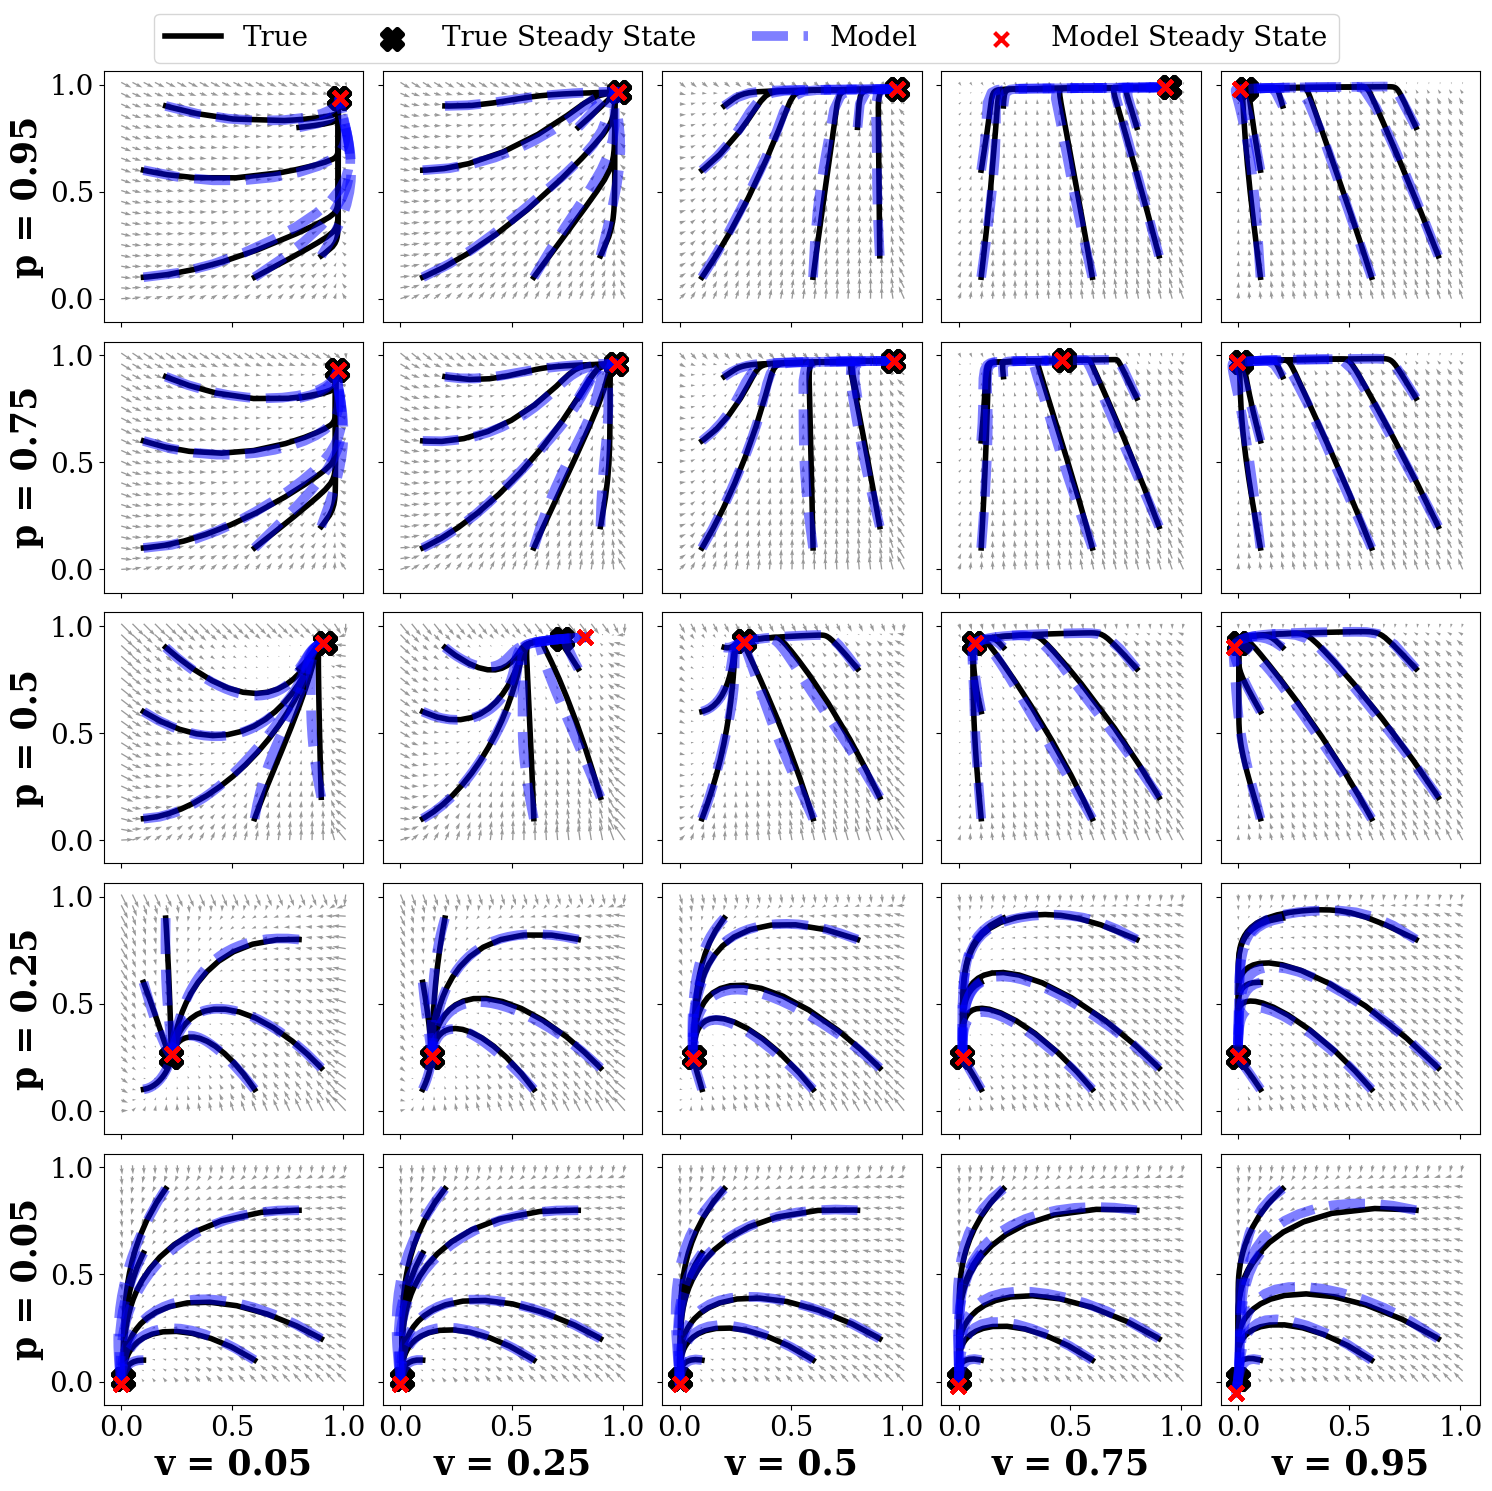

In [9]:
fig_scale = 3
figsize = (int(fig_scale*len(p_vals)), int(fig_scale*len(v_vals)))

fig, axes = plt.subplots(
    len(p_vals), len(v_vals),
    figsize=figsize,
    # constrained_layout=True,
    sharex=True,
    sharey=True
)

Ti = torch.linspace(t_span[0], t_span[-1], 501, dtype=torch.float32)

for i, pi in enumerate(tqdm(p_vals[::-1])):
    for j, vj in enumerate(v_vals):
        ax = axes[i, j]

        # ======================================================
        # TRUE VECTOR FIELD
        # ======================================================
        U = np.zeros_like(X1)
        V = np.zeros_like(X2)

        for ii in range(X1.shape[0]):
            for jj in range(X1.shape[1]):
                x = np.array([X1[ii, jj], X2[ii, jj]])
                dxdt = two_tank_system(0, x, (pi, vj))
                U[ii, jj] = dxdt[0]
                V[ii, jj] = dxdt[1]

        ax.quiver(
            X1, X2, U, V,
            angles='xy',
            scale_units='xy',
            width=0.005,
            color='grey',
            alpha=0.8
        )

        # ======================================================
        # TRUE TRAJECTORIES (solid)
        # ======================================================
        for idx, x0 in enumerate(x_inits):
            label = None
            if idx ==0:
                label = "True"
            sol_true = sp_solve_ivp(
                lambda t, y: two_tank_system(t, y, (pi, vj)),
                t_span,
                x0,
                rtol=1e-6,
                atol=1e-9
            )

            ax.plot(
                sol_true.y[0],
                sol_true.y[1],
                '-',
                c='black',
                lw=4,
                zorder=1,
                label=label
            )
            label=None
            if idx ==0:
                label = "True Steady State"
            x_last = sol_true.y[:, -1]
            ax.scatter(
                x_last[0], x_last[1],
                marker='X',
                s=200,
                c='black',
                lw=4,
                zorder=3,
                label=label
            )

        # ======================================================
        # MODEL TRAJECTORIES (dashed) — unsplit standard NODE
        # ======================================================
        x0_torch = torch.tensor(x_inits, dtype=torch.float32)
        n_x0, dim_x0 = x0_torch.shape

        control = lambda t: torch.tensor([pi, vj], dtype=torch.float32).expand(n_x0, dim_x0)
        # Unsplit model: forward(x, u) -> dx/dt (no t / u_func)
        func = lambda t, x: model_unsplit(x, control(t))

        with torch.no_grad():
            sol_model = torchode.solve_ivp(
                f=func,
                y0=x0_torch,
                t_eval=Ti,
            )

        for idx,traj in enumerate(sol_model.ys):
            label=None
            if idx ==0:
                label = "Model"
            ax.plot(
                traj[:, 0].numpy(),
                traj[:, 1].numpy(),
                '--',              # <-- dashed
                lw=7,
                color='blue',
                alpha=0.5,
                zorder=3,
                label = label
            )
            x_last = traj[-1,:].numpy()
            
            label = None
            if idx ==0:
                label = "Model Steady State"
            ax.scatter(x_last[0],x_last[1], marker='x',s=100,c='red',lw=3,zorder=4,label =label)


        # ======================================================
        # LABELS / FORMATTING
        # ======================================================
        if j == 0:
            ax.set_ylabel(f"p = {pi}", size=25, fontweight='bold')

        if i == len(v_vals) - 1:
            ax.set_xlabel(f"v = {vj}", size=25, fontweight='bold')

        ax.tick_params(axis='both', which='major', labelsize=20)

# plt.suptitle(
#     "Phase Portrait: True System (solid) vs Unsplit Model (dashed)",
#     size=60
# )

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5,fontsize=20)

plt.tight_layout(rect=[0,0,1,0.96])
# plt.savefig("mixing-tanks-phase-portrait-unsplit.png")
plt.show()

In [10]:
from torch.autograd.functional import jacobian as torch_jacobian

n_p, n_v, n_traj = len(p_vals), len(v_vals), len(x_inits)

# eigenvalues_unsplit[p_idx, v_idx, traj_idx, eig_idx] — complex
# p_idx indexes p_vals, v_idx indexes v_vals, traj_idx indexes x_inits
eigenvalues_unsplit = np.empty((n_p, n_v, n_traj, 2), dtype=complex)

t_fixed = torch.tensor(0.0, dtype=torch.float32)
x0_torch = torch.tensor(x_inits, dtype=torch.float32)

model_unsplit.eval()

for i, pi in enumerate(tqdm(p_vals, desc='p')):
    for j, vj in enumerate(v_vals):
        u = torch.tensor([pi, vj], dtype=torch.float32)

        # Simulate model to find steady states x*
        ctrl_fn = lambda t, _u=u: _u.expand(n_traj, 2)

        with torch.no_grad():
            sol_model = torchode.solve_ivp(
                f=lambda t, x, _c=ctrl_fn: model_unsplit(x, _c(t)),
                y0=x0_torch,
                t_eval=Ti,
            )

        # Jacobian of model dynamics at each x*
        for k, traj in enumerate(sol_model.ys):
            x_star = traj[-1, :].detach().clone()  # [2]

            def f_jac(x, _u=u):
                # Unsplit model: forward(x, u) -> dx/dt
                return model_unsplit(x.unsqueeze(0), _u.unsqueeze(0)).squeeze(0)

            J = torch_jacobian(f_jac, x_star)  # [2, 2]
            eigenvalues_unsplit[i, j, k] = np.linalg.eigvals(J.detach().numpy())

print(f"eigenvalues shape: {eigenvalues_unsplit.shape}  (n_p, n_v, n_traj, 2)")
print(f"All Hurwitz stable [Re(λ) < 0]: {np.all(eigenvalues_unsplit.real < 0)}")
print(f"Max real part across all cases:  {eigenvalues_unsplit.real.max():.6f}")

p:   0%|          | 0/5 [00:00<?, ?it/s]

eigenvalues shape: (5, 5, 6, 2)  (n_p, n_v, n_traj, 2)
All Hurwitz stable [Re(λ) < 0]: True
Max real part across all cases:  -0.011529


In [11]:
eigenvalues_unsplit

array([[[[-0.10716084+0.j, -0.07050619+0.j],
         [-0.10716088+0.j, -0.07050626+0.j],
         [-0.10716084+0.j, -0.07050624+0.j],
         [-0.10716069+0.j, -0.07050622+0.j],
         [-0.10716067+0.j, -0.07050617+0.j],
         [-0.10716069+0.j, -0.0705062 +0.j]],

        [[-0.11649234+0.j, -0.07248097+0.j],
         [-0.11649292+0.j, -0.0724811 +0.j],
         [-0.11649259+0.j, -0.07248101+0.j],
         [-0.11649249+0.j, -0.07248101+0.j],
         [-0.11649236+0.j, -0.072481  +0.j],
         [-0.11649239+0.j, -0.07248097+0.j]],

        [[-0.12979147+0.j, -0.06952218+0.j],
         [-0.12979154+0.j, -0.06952219+0.j],
         [-0.12979148+0.j, -0.06952218+0.j],
         [-0.12979154+0.j, -0.06952221+0.j],
         [-0.12979166+0.j, -0.06952222+0.j],
         [-0.12979144+0.j, -0.06952217+0.j]],

        [[-0.14029548+0.j, -0.0581545 +0.j],
         [-0.1402954 +0.j, -0.05815454+0.j],
         [-0.14029554+0.j, -0.05815449+0.j],
         [-0.14029536+0.j, -0.05815457+0.j],
    

# Unsplit (standard NODE) model [20-20-20]— Hurwitz analysis

Same phase-portrait comparison (true vs. model) and steady-state eigenvalue (Hurwitz) check as above, but for the **standard NODE** `GeluSigmoidMLP([4, 20, 20, 20, 2])` trained without the `f`/`g` split.

Reuses the system definition, the `(p_vals, v_vals)` grid, the initial conditions `x_inits`, the vector-field grid `X1`/`X2`, and the time grid `Ti` defined earlier. The only structural difference is that the unsplit model's `forward(x, u)` consumes state and control directly (no `t` / `u_func`), so the integration and Jacobian closures call `model_unsplit(x, u)`.

In [12]:
# Standard NODE (unsplit): dx/dt = NN(x, u), no f/g split.
# Input dim 4 = state (2) + control (2), output dim 2.
model_unsplit_2 = GeluSigmoidMLP(dims=[4,20,20,20,2], lower_bound=-1, upper_bound=1).to(device)

model_unsplit_2_path = "../best_model-unsplit-20-20-20.pth"

model_unsplit_2.load_state_dict(torch.load(model_unsplit_2_path))

model_unsplit_2.eval()

GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=4, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)

  0%|          | 0/5 [00:00<?, ?it/s]

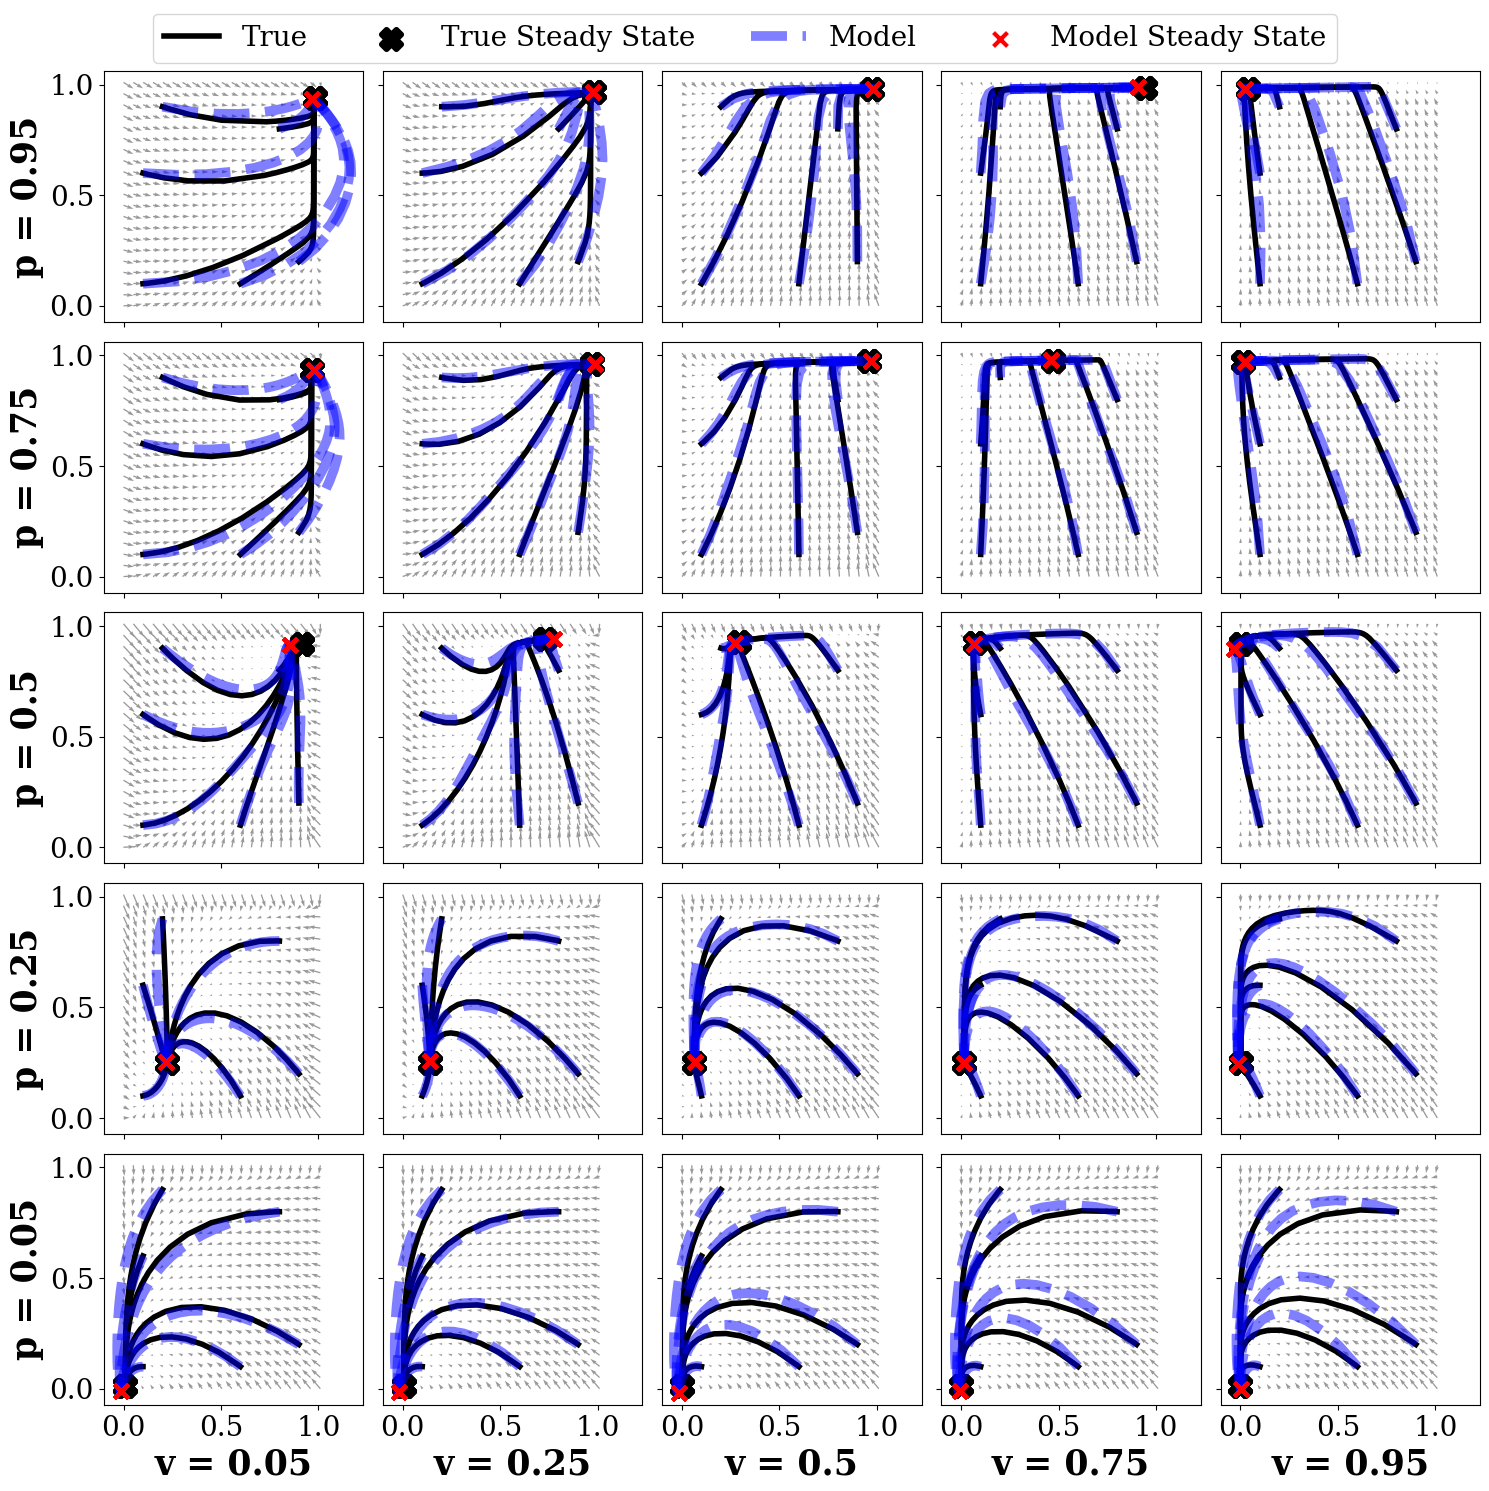

In [20]:
fig_scale = 3
figsize = (int(fig_scale*len(p_vals)), int(fig_scale*len(v_vals)))

fig, axes = plt.subplots(
    len(p_vals), len(v_vals),
    figsize=figsize,
    # constrained_layout=True,
    sharex=True,
    sharey=True
)

Ti = torch.linspace(t_span[0], t_span[-1], 501, dtype=torch.float32)

for i, pi in enumerate(tqdm(p_vals[::-1])):
    for j, vj in enumerate(v_vals):
        ax = axes[i, j]

        # ======================================================
        # TRUE VECTOR FIELD
        # ======================================================
        U = np.zeros_like(X1)
        V = np.zeros_like(X2)

        for ii in range(X1.shape[0]):
            for jj in range(X1.shape[1]):
                x = np.array([X1[ii, jj], X2[ii, jj]])
                dxdt = two_tank_system(0, x, (pi, vj))
                U[ii, jj] = dxdt[0]
                V[ii, jj] = dxdt[1]

        ax.quiver(
            X1, X2, U, V,
            angles='xy',
            scale_units='xy',
            width=0.005,
            color='grey',
            alpha=0.8
        )

        # ======================================================
        # TRUE TRAJECTORIES (solid)
        # ======================================================
        for idx, x0 in enumerate(x_inits):
            label = None
            if idx ==0:
                label = "True"
            sol_true = sp_solve_ivp(
                lambda t, y: two_tank_system(t, y, (pi, vj)),
                t_span,
                x0,
                rtol=1e-6,
                atol=1e-9
            )

            ax.plot(
                sol_true.y[0],
                sol_true.y[1],
                '-',
                c='black',
                lw=4,
                zorder=1,
                label=label
            )
            label=None
            if idx ==0:
                label = "True Steady State"
            x_last = sol_true.y[:, -1]
            ax.scatter(
                x_last[0], x_last[1],
                marker='X',
                s=200,
                c='black',
                lw=4,
                zorder=3,
                label=label
            )

        # ======================================================
        # MODEL TRAJECTORIES (dashed) — unsplit standard NODE
        # ======================================================
        x0_torch = torch.tensor(x_inits, dtype=torch.float32)
        n_x0, dim_x0 = x0_torch.shape

        control = lambda t: torch.tensor([pi, vj], dtype=torch.float32).expand(n_x0, dim_x0)
        # Unsplit model: forward(x, u) -> dx/dt (no t / u_func)
        func = lambda t, x: model_unsplit_2(x, control(t))

        with torch.no_grad():
            sol_model = torchode.solve_ivp(
                f=func,
                y0=x0_torch,
                t_eval=Ti,
            )

        for idx,traj in enumerate(sol_model.ys):
            label=None
            if idx ==0:
                label = "Model"
            ax.plot(
                traj[:, 0].numpy(),
                traj[:, 1].numpy(),
                '--',              
                lw=7,
                color='blue',
                alpha=0.5,
                zorder=3,
                label = label
            )
            x_last = traj[-1,:].numpy()
            
            label = None
            if idx ==0:
                label = "Model Steady State"
            ax.scatter(x_last[0],x_last[1], marker='x',s=100,c='red',lw=3,zorder=4,label =label)


        # ======================================================
        # LABELS / FORMATTING
        # ======================================================
        if j == 0:
            ax.set_ylabel(f"p = {pi}", size=25, fontweight='bold')

        if i == len(v_vals) - 1:
            ax.set_xlabel(f"v = {vj}", size=25, fontweight='bold')

        ax.tick_params(axis='both', which='major', labelsize=20)

# plt.suptitle(
#     "Phase Portrait: True System (solid) vs Unsplit Model (dashed)",
#     size=60
# )

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5,fontsize=20)

plt.tight_layout(rect=[0,0,1,0.96])
# plt.savefig("mixing-tanks-phase-portrait-unsplit.png")
plt.show()

In [14]:
from torch.autograd.functional import jacobian as torch_jacobian

n_p, n_v, n_traj = len(p_vals), len(v_vals), len(x_inits)

# eigenvalues_unsplit[p_idx, v_idx, traj_idx, eig_idx] — complex
# p_idx indexes p_vals, v_idx indexes v_vals, traj_idx indexes x_inits
eigenvalues_unsplit_2 = np.empty((n_p, n_v, n_traj, 2), dtype=complex)

t_fixed = torch.tensor(0.0, dtype=torch.float32)
x0_torch = torch.tensor(x_inits, dtype=torch.float32)

model_unsplit_2.eval()

for i, pi in enumerate(tqdm(p_vals, desc='p')):
    for j, vj in enumerate(v_vals):
        u = torch.tensor([pi, vj], dtype=torch.float32)

        # Simulate model to find steady states x*
        ctrl_fn = lambda t, _u=u: _u.expand(n_traj, 2)

        with torch.no_grad():
            sol_model = torchode.solve_ivp(
                f=lambda t, x, _c=ctrl_fn: model_unsplit_2(x, _c(t)),
                y0=x0_torch,
                t_eval=Ti,
            )

        # Jacobian of model dynamics at each x*
        for k, traj in enumerate(sol_model.ys):
            x_star = traj[-1, :].detach().clone()  # [2]

            def f_jac(x, _u=u):
                # Unsplit model: forward(x, u) -> dx/dt
                return model_unsplit_2(x.unsqueeze(0), _u.unsqueeze(0)).squeeze(0)

            J = torch_jacobian(f_jac, x_star)  # [2, 2]
            eigenvalues_unsplit_2[i, j, k] = np.linalg.eigvals(J.detach().numpy())

print(f"eigenvalues shape: {eigenvalues_unsplit_2.shape}  (n_p, n_v, n_traj, 2)")
print(f"All Hurwitz stable [Re(λ) < 0]: {np.all(eigenvalues_unsplit_2.real < 0)}")
print(f"Max real part across all cases:  {eigenvalues_unsplit_2.real.max():.6f}")

p:   0%|          | 0/5 [00:00<?, ?it/s]

eigenvalues shape: (5, 5, 6, 2)  (n_p, n_v, n_traj, 2)
All Hurwitz stable [Re(λ) < 0]: True
Max real part across all cases:  -0.004848


# Steady-state absolute error — split vs. unsplit case 1 and 2

Computes the absolute difference between each model's steady state and the true
steady state, for all **6 trajectories** across all **25 control scenarios** (the 5×5
`p`×`v` grid).

- `true_ss`, `split_ss`, `unsplit_ss` — steady states of shape `(5, 5, 6, 2)`, taken as the
  endpoint of the integrated trajectory over the horizon `t_span`.
- `abs_err_split`, `abs_err_unsplit` — elementwise `|model_ss - true_ss|`, shape `(5, 5, 6, 2)`,
  indexed `[p_idx, v_idx, traj_idx, {x1, x2}]` consistently with the eigenvalue arrays above.

In [15]:
# True steady states: integrate the true system to the horizon (t_span) for
# every (p, v) control scenario and every initial condition; take the final point.
# Indexing: [p_idx, v_idx, traj_idx, state] with state in {x1, x2}.
n_p, n_v, n_traj = len(p_vals), len(v_vals), len(x_inits)

true_ss = np.empty((n_p, n_v, n_traj, 2))

for i, pi in enumerate(tqdm(p_vals, desc='true')):
    for j, vj in enumerate(v_vals):
        for k, x0 in enumerate(x_inits):
            sol_true = sp_solve_ivp(
                lambda t, y: two_tank_system(t, y, (pi, vj)),
                t_span,
                x0,
                rtol=1e-6,
                atol=1e-9,
            )
            true_ss[i, j, k] = sol_true.y[:, -1]

print(f"true_ss shape: {true_ss.shape}  (n_p, n_v, n_traj, 2)")

true:   0%|          | 0/5 [00:00<?, ?it/s]

true_ss shape: (5, 5, 6, 2)  (n_p, n_v, n_traj, 2)


In [21]:
# Model steady states: integrate each model (batched over the 6 trajectories)
# to the horizon Ti and take the final point, for every control scenario.
# Same indexing as true_ss and the eigenvalue arrays: [p_idx, v_idx, traj_idx, state].
x0_torch = torch.tensor(x_inits, dtype=torch.float32)
n_x0, dim_x0 = x0_torch.shape


def model_steady_states(rhs, desc):
    """rhs(t, x, control) -> dx/dt for batched state x [n_traj, 2].

    `control(t)` returns the [n_traj, 2] control tensor. Returns [n_p, n_v, n_traj, 2].
    """
    ss = np.empty((n_p, n_v, n_traj, 2))
    for i, pi in enumerate(tqdm(p_vals, desc=desc)):
        for j, vj in enumerate(v_vals):
            control = lambda t, _p=pi, _v=vj: torch.tensor(
                [_p, _v], dtype=torch.float32
            ).expand(n_x0, dim_x0)
            with torch.no_grad():
                sol_model = torchode.solve_ivp(
                    f=lambda t, x, _c=control: rhs(t, x, _c),
                    y0=x0_torch,
                    t_eval=Ti,
                )
            for k, traj in enumerate(sol_model.ys):
                ss[i, j, k] = traj[-1, :].numpy()
    return ss


# Split FTNODE: model(t, x, u_func). Unsplit standard NODE: model_unsplit(x, u).
split_ss   = model_steady_states(lambda t, x, c: model(t, x, c),          desc='split')
unsplit_ss = model_steady_states(lambda t, x, c: model_unsplit(x, c(t)),  desc='unsplit')
unsplit_2_ss = model_steady_states(lambda t, x, c: model_unsplit_2(x, c(t)),  desc='unsplit 2')

print(f"split_ss   shape: {split_ss.shape}")
print(f"unsplit_ss shape: {unsplit_ss.shape}")
print(f"unsplit_2_ss shape: {unsplit_2_ss.shape}")

split:   0%|          | 0/5 [00:00<?, ?it/s]

unsplit:   0%|          | 0/5 [00:00<?, ?it/s]

unsplit 2:   0%|          | 0/5 [00:00<?, ?it/s]

split_ss   shape: (5, 5, 6, 2)
unsplit_ss shape: (5, 5, 6, 2)
unsplit_2_ss shape: (5, 5, 6, 2)


In [22]:
# Absolute steady-state error per state component: |model_ss - true_ss|
# Shape: (n_p, n_v, n_traj, 2) — indexed [p_idx, v_idx, traj_idx, {x1, x2}].
abs_err_split   = np.abs(split_ss   - true_ss)
abs_err_unsplit = np.abs(unsplit_ss - true_ss)
abs_err_unsplit_2 = np.abs(unsplit_2_ss - true_ss)

print(f"abs_err_split   shape: {abs_err_split.shape}  (n_p, n_v, n_traj, 2)")
print(f"abs_err_unsplit shape: {abs_err_unsplit.shape}  (n_p, n_v, n_traj, 2)")
print(f"abs_err_unsplit_2 shape: {abs_err_unsplit_2.shape}  (n_p, n_v, n_traj, 2)")
print(f"Split   — mean |err|: {abs_err_split.mean():.6e}, max |err|: {abs_err_split.max():.6e}")
print(f"Unsplit — mean |err|: {abs_err_unsplit.mean():.6e}, max |err|: {abs_err_unsplit.max():.6e}")
print(f"Unsplit_2 — mean |err|: {abs_err_unsplit_2.mean():.6e}, max |err|: {abs_err_unsplit_2.max():.6e}")

abs_err_split   shape: (5, 5, 6, 2)  (n_p, n_v, n_traj, 2)
abs_err_unsplit shape: (5, 5, 6, 2)  (n_p, n_v, n_traj, 2)
abs_err_unsplit_2 shape: (5, 5, 6, 2)  (n_p, n_v, n_traj, 2)
Split   — mean |err|: 5.587425e-03, max |err|: 4.488334e-02
Unsplit — mean |err|: 1.011476e-02, max |err|: 1.042576e-01
Unsplit_2 — mean |err|: 1.161753e-02, max |err|: 6.181347e-02


In [18]:
abs_err_split

array([[[[6.42206130e-03, 1.14265273e-02],
         [6.42206124e-03, 1.14266198e-02],
         [6.42208469e-03, 1.14265325e-02],
         [6.42212094e-03, 1.14263664e-02],
         [6.42206967e-03, 1.14264809e-02],
         [6.42205674e-03, 1.14266799e-02]],

        [[4.66303825e-03, 1.27457622e-02],
         [4.66280315e-03, 1.27454360e-02],
         [4.66300414e-03, 1.27458539e-02],
         [4.66300222e-03, 1.27457871e-02],
         [4.66304114e-03, 1.27457655e-02],
         [4.66289984e-03, 1.27457086e-02]],

        [[2.11096810e-03, 1.25534005e-02],
         [2.11097640e-03, 1.25534146e-02],
         [2.11102273e-03, 1.25533686e-02],
         [2.11096691e-03, 1.25532967e-02],
         [2.11099032e-03, 1.25531856e-02],
         [2.11100318e-03, 1.25532847e-02]],

        [[5.61920829e-04, 1.11235983e-02],
         [5.61908959e-04, 1.11231152e-02],
         [5.61927781e-04, 1.11235555e-02],
         [5.61917303e-04, 1.11233932e-02],
         [5.61929643e-04, 1.11234776e-02],
     

In [19]:
abs_err_unsplit

array([[[[1.15401057e-02, 2.25789758e-02],
         [1.15403230e-02, 2.25790156e-02],
         [1.15401692e-02, 2.25790228e-02],
         [1.15400666e-02, 2.25785091e-02],
         [1.15398899e-02, 2.25785436e-02],
         [1.15399559e-02, 2.25785933e-02]],

        [[5.97002647e-03, 2.11962946e-02],
         [5.97087526e-03, 2.11983223e-02],
         [5.97023232e-03, 2.11974118e-02],
         [5.97029444e-03, 2.11967698e-02],
         [5.97012746e-03, 2.11964682e-02],
         [5.97017559e-03, 2.11964525e-02]],

        [[3.15435052e-03, 2.15878904e-02],
         [3.15438674e-03, 2.15884658e-02],
         [3.15440870e-03, 2.15879075e-02],
         [3.15449734e-03, 2.15882056e-02],
         [3.15465385e-03, 2.15884024e-02],
         [3.15432248e-03, 2.15876570e-02]],

        [[3.31782885e-03, 3.16371129e-02],
         [3.31756156e-03, 3.16366218e-02],
         [3.31793971e-03, 3.16375244e-02],
         [3.31750409e-03, 3.16371336e-02],
         [3.31789501e-03, 3.16372038e-02],
     